# GMM Classification and OOD Evaluation on SNGP Embeddings

Load saved SNGP embeddings, fit one Gaussian per CIFAR-10 class using the training labels as the latent variable `z`, evaluate GMM classification on CIFAR-10 test embeddings, and evaluate SVHN and CIFAR-100 OOD detection with `-log p(x)`.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    import umap
except ImportError:
    umap = None

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    if (candidate / "src").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError(f"Could not find repo root from {cwd}")

os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

print("repo root:", REPO_ROOT)


/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo root: /w/20252/wjcai/uq/manygp


In [2]:
EMBEDDING_PATH = REPO_ROOT / "notebooks" / "gmm" / "sngp_embeddings_cifar10_sngp_epoch175_acc0.9323.npz"

if not EMBEDDING_PATH.exists():
    candidates = sorted((REPO_ROOT / "notebooks" / "gmm").glob("sngp_embeddings_*.npz"))
    if not candidates:
        raise FileNotFoundError("No sngp_embeddings_*.npz files found in notebooks/gmm")
    EMBEDDING_PATH = candidates[-1]

data = np.load(EMBEDDING_PATH, allow_pickle=True)

train_embeddings = data["train_embeddings"].astype(np.float64)
train_labels = data["train_labels"].astype(np.int64)
test_embeddings = data["test_embeddings"].astype(np.float64)
test_labels = data["test_labels"].astype(np.int64)
svhn_embeddings = data["svhn_embeddings"].astype(np.float64) if "svhn_embeddings" in data else None
svhn_labels = data["svhn_labels"].astype(np.int64) if "svhn_labels" in data else None
cifar100_test_embeddings = data["cifar100_test_embeddings"].astype(np.float64) if "cifar100_test_embeddings" in data else None
cifar100_test_labels = data["cifar100_test_labels"].astype(np.int64) if "cifar100_test_labels" in data else None
classes = data["classes"]
checkpoint_id = str(data["checkpoint_id"]) if "checkpoint_id" in data else EMBEDDING_PATH.stem.removeprefix("sngp_embeddings_")

print("embedding file:", EMBEDDING_PATH)
print("checkpoint id:", checkpoint_id)
print("train embeddings:", train_embeddings.shape)
print("test embeddings:", test_embeddings.shape)
if svhn_embeddings is not None:
    print("svhn embeddings:", svhn_embeddings.shape)
if cifar100_test_embeddings is not None:
    print("cifar100 test embeddings:", cifar100_test_embeddings.shape)
print("classes:", classes.tolist())


embedding file: /w/20252/wjcai/uq/manygp/notebooks/gmm/sngp_embeddings_cifar10_sngp_epoch175_acc0.9323.npz
checkpoint id: cifar10_sngp_epoch175_acc0.9323
train embeddings: (50000, 128)
test embeddings: (10000, 128)
svhn embeddings: (26032, 128)
cifar100 test embeddings: (10000, 128)
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Fit two density models on the saved training embeddings.

Method 1 fixes the latent variable with labels: `z = y`. The class prior `p(z)` is the empirical class frequency in the training set, and `p(x | z)` is a full-covariance Gaussian estimated from the embeddings for that class.

Method 2 ignores the labels during fitting and runs a standard EM update for a full-covariance GMM with `K = num_classes` components. That EM-fitted GMM is used for density-based OOD scoring with `-log p(x)` on CIFAR-10 test embeddings versus SVHN and CIFAR-100 embeddings.



In [3]:
def fit_label_assigned_gmm(x, y, num_classes, covariance_reg=1e-3):
    dim = x.shape[1]
    means = np.zeros((num_classes, dim), dtype=np.float64)
    covariances = np.zeros((num_classes, dim, dim), dtype=np.float64)
    priors = np.zeros(num_classes, dtype=np.float64)

    global_variance = np.var(x, axis=0).mean()
    reg = covariance_reg * max(global_variance, 1e-12)

    for cls in range(num_classes):
        class_x = x[y == cls]
        if len(class_x) == 0:
            raise ValueError(f"class {cls} has no training samples")

        priors[cls] = len(class_x) / len(x)
        means[cls] = class_x.mean(axis=0)
        centered = class_x - means[cls]
        cov = centered.T @ centered / max(len(class_x) - 1, 1)
        covariances[cls] = cov + reg * np.eye(dim)

    return priors, means, covariances, reg


def fit_em_gmm(x, num_components, covariance_reg=1e-3, max_iter=100, tol=1e-3, random_state=42):
    from sklearn.mixture import GaussianMixture

    global_variance = np.var(x, axis=0).mean()
    reg = covariance_reg * max(global_variance, 1e-12)

    model = GaussianMixture(
        n_components=num_components,
        covariance_type="full",
        reg_covar=reg,
        max_iter=max_iter,
        tol=tol,
        random_state=random_state,
        init_params="kmeans",
    )
    model.fit(x)

    return (
        model.weights_.astype(np.float64),
        model.means_.astype(np.float64),
        model.covariances_.astype(np.float64),
        reg,
        model,
    )


num_classes = len(classes)
class_priors, class_means, class_covariances, covariance_reg = fit_label_assigned_gmm(
    train_embeddings,
    train_labels,
    num_classes=num_classes,
    covariance_reg=1e-3,
)

em_priors, em_means, em_covariances, em_covariance_reg, em_model = fit_em_gmm(
    train_embeddings,
    num_components=num_classes,
    covariance_reg=1e-3,
    max_iter=100,
    tol=1e-3,
    random_state=42,
)

print("label-assigned class priors:", np.round(class_priors, 4))
print("label-assigned covariance diagonal regularizer:", covariance_reg)
print("EM GMM mixture weights:", np.round(em_priors, 4))
print("EM GMM covariance diagonal regularizer:", em_covariance_reg)
print("EM GMM converged:", em_model.converged_)
print("EM GMM iterations:", em_model.n_iter_)
print("EM GMM lower bound:", em_model.lower_bound_)



label-assigned class priors: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
label-assigned covariance diagonal regularizer: 0.0006467281316112034
EM GMM mixture weights: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
EM GMM covariance diagonal regularizer: 0.0006467281316112034
EM GMM converged: True
EM GMM iterations: 2
EM GMM lower bound: 289.01875683118254


In [4]:
def logsumexp(a, axis=None, keepdims=False):
    a_max = np.max(a, axis=axis, keepdims=True)
    out = a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))
    if not keepdims:
        out = np.squeeze(out, axis=axis)
    return out


def gaussian_logpdf_by_class(x, means, covariances):
    num_classes, dim = means.shape
    logpdf = np.empty((x.shape[0], num_classes), dtype=np.float64)
    log_2pi = dim * np.log(2.0 * np.pi)

    for cls in range(num_classes):
        chol = np.linalg.cholesky(covariances[cls])
        diff = (x - means[cls]).T
        solved = np.linalg.solve(chol, diff)
        mahalanobis = np.sum(solved * solved, axis=0)
        logdet = 2.0 * np.sum(np.log(np.diag(chol)))
        logpdf[:, cls] = -0.5 * (log_2pi + logdet + mahalanobis)

    return logpdf


def gmm_probabilities(x, priors, means, covariances):
    log_likelihood = gaussian_logpdf_by_class(x, means, covariances)
    log_joint = np.log(priors)[None, :] + log_likelihood
    log_px = logsumexp(log_joint, axis=1)
    posterior = np.exp(log_joint - log_px[:, None])

    return {
        "log_likelihood": log_likelihood,
        "log_joint": log_joint,
        "log_px": log_px,
        "posterior": posterior,
    }


train_gmm = gmm_probabilities(train_embeddings, class_priors, class_means, class_covariances)
test_gmm = gmm_probabilities(
    test_embeddings,
    class_priors,
    class_means,
    class_covariances,
)

em_train_gmm = gmm_probabilities(train_embeddings, em_priors, em_means, em_covariances)
em_test_gmm = gmm_probabilities(
    test_embeddings,
    em_priors,
    em_means,
    em_covariances,
)

print("label-assigned train log p(x) range:", (train_gmm["log_px"].min(), train_gmm["log_px"].max()))
print("label-assigned test log p(x) range:", (test_gmm["log_px"].min(), test_gmm["log_px"].max()))
print("EM GMM train log p(x) range:", (em_train_gmm["log_px"].min(), em_train_gmm["log_px"].max()))
print("EM GMM test log p(x) range:", (em_test_gmm["log_px"].min(), em_test_gmm["log_px"].max()))



label-assigned train log p(x) range: (np.float64(192.00931832518788), np.float64(299.78153319426934))
label-assigned test log p(x) range: (np.float64(187.19268158395099), np.float64(299.511736032729))
EM GMM train log p(x) range: (np.float64(191.99985190590183), np.float64(299.77152215409365))
EM GMM test log p(x) range: (np.float64(187.17908273356898), np.float64(299.5029318047966))


For classification and calibration, use the GMM posterior directly: `p_gmm(y | x) = p(x, z=y) / p(x)`. The notebook no longer blends the posterior with a uniform distribution, since `p(x)` is a density rather than a probability weight.



In [5]:
def negative_log_likelihood(probs, labels, eps=1e-12):
    true_class_probs = probs[np.arange(len(labels)), labels]
    return -np.mean(np.log(np.clip(true_class_probs, eps, 1.0)))


def classification_ece(probs, labels, n_bins=15):
    """Match src/training/evaluate.py::_classification_ece."""
    confidences = probs.max(axis=-1)
    preds = probs.argmax(axis=-1)
    correct = (preds == labels).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(confidences)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences >= lo) & (confidences < hi)
        if not np.any(mask):
            continue
        bin_acc = correct[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return float(ece)


def calibration_bins(probs, labels, n_bins=15):
    confidences = probs.max(axis=-1)
    preds = probs.argmax(axis=-1)
    correct = (preds == labels).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_acc = np.full(n_bins, np.nan, dtype=np.float64)
    bin_conf = np.full(n_bins, np.nan, dtype=np.float64)
    bin_frac = np.zeros(n_bins, dtype=np.float64)

    for idx, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        mask = (confidences >= lo) & (confidences < hi)
        if not np.any(mask):
            continue
        bin_acc[idx] = correct[mask].mean()
        bin_conf[idx] = confidences[mask].mean()
        bin_frac[idx] = mask.mean()

    return {
        "bin_edges": bin_edges,
        "bin_centers": bin_centers,
        "bin_acc": bin_acc,
        "bin_conf": bin_conf,
        "bin_frac": bin_frac,
    }


train_posterior_pred = train_gmm["posterior"].argmax(axis=1)
test_posterior_pred = test_gmm["posterior"].argmax(axis=1)

train_posterior_acc = np.mean(train_posterior_pred == train_labels)
test_posterior_acc = np.mean(test_posterior_pred == test_labels)

train_posterior_ece = classification_ece(train_gmm["posterior"], train_labels)
test_posterior_ece = classification_ece(test_gmm["posterior"], test_labels)
train_calibration = calibration_bins(train_gmm["posterior"], train_labels)
test_calibration = calibration_bins(test_gmm["posterior"], test_labels)

train_posterior_nll = negative_log_likelihood(train_gmm["posterior"], train_labels)
test_posterior_nll = negative_log_likelihood(test_gmm["posterior"], test_labels)

train_entropy = -(np.clip(train_gmm["posterior"], 1e-12, 1.0) * np.log(np.clip(train_gmm["posterior"], 1e-12, 1.0))).sum(axis=1)
test_entropy = -(np.clip(test_gmm["posterior"], 1e-12, 1.0) * np.log(np.clip(test_gmm["posterior"], 1e-12, 1.0))).sum(axis=1)
train_correct_mask = train_posterior_pred == train_labels
test_correct_mask = test_posterior_pred == test_labels

print(f"train GMM posterior accuracy: {train_posterior_acc * 100:.2f}%")
print(f"train GMM posterior ECE: {train_posterior_ece:.4f}")
print(f"train GMM posterior NLL: {train_posterior_nll:.4f}")
print(f"test GMM posterior accuracy: {test_posterior_acc * 100:.2f}%")
print(f"test GMM posterior ECE: {test_posterior_ece:.4f}")
print(f"test GMM posterior NLL: {test_posterior_nll:.4f}")



train GMM posterior accuracy: 99.99%
train GMM posterior ECE: 0.0001
train GMM posterior NLL: 0.0005
test GMM posterior accuracy: 92.92%
test GMM posterior ECE: 0.0422
test GMM posterior NLL: 1.4954


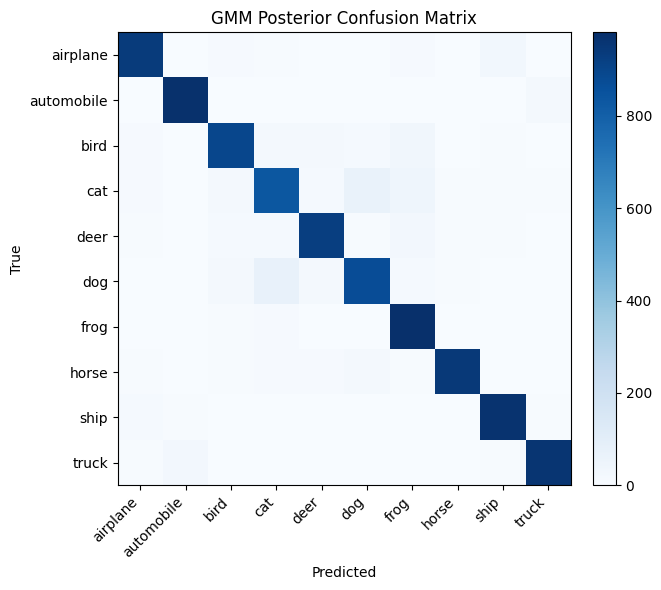

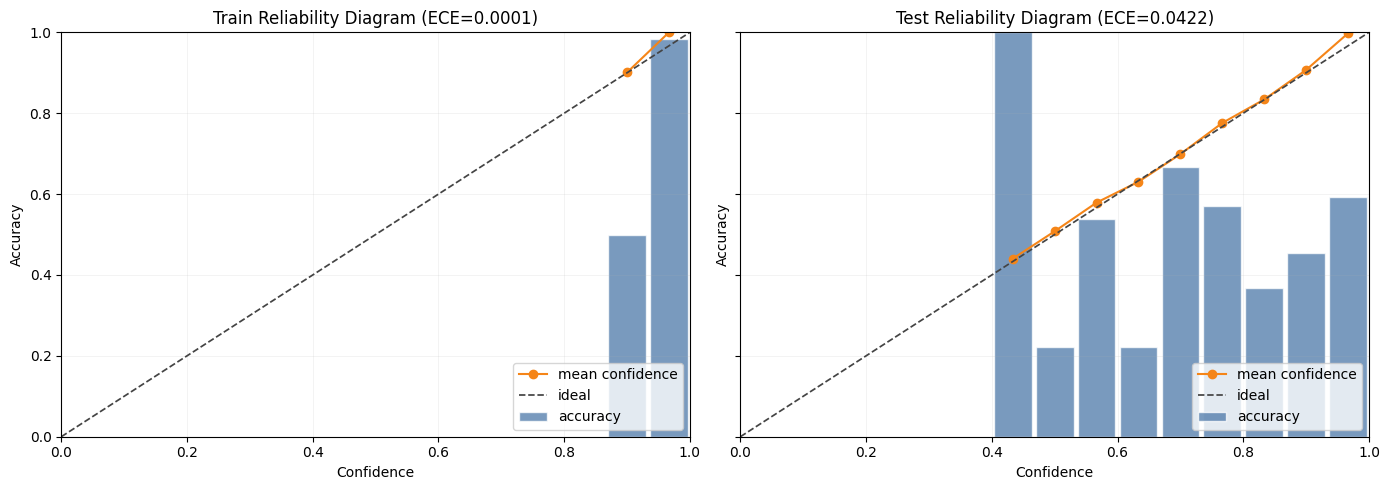

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


computed train/test/svhn UMAP: (50000, 2) (10000, 2) (26032, 2)


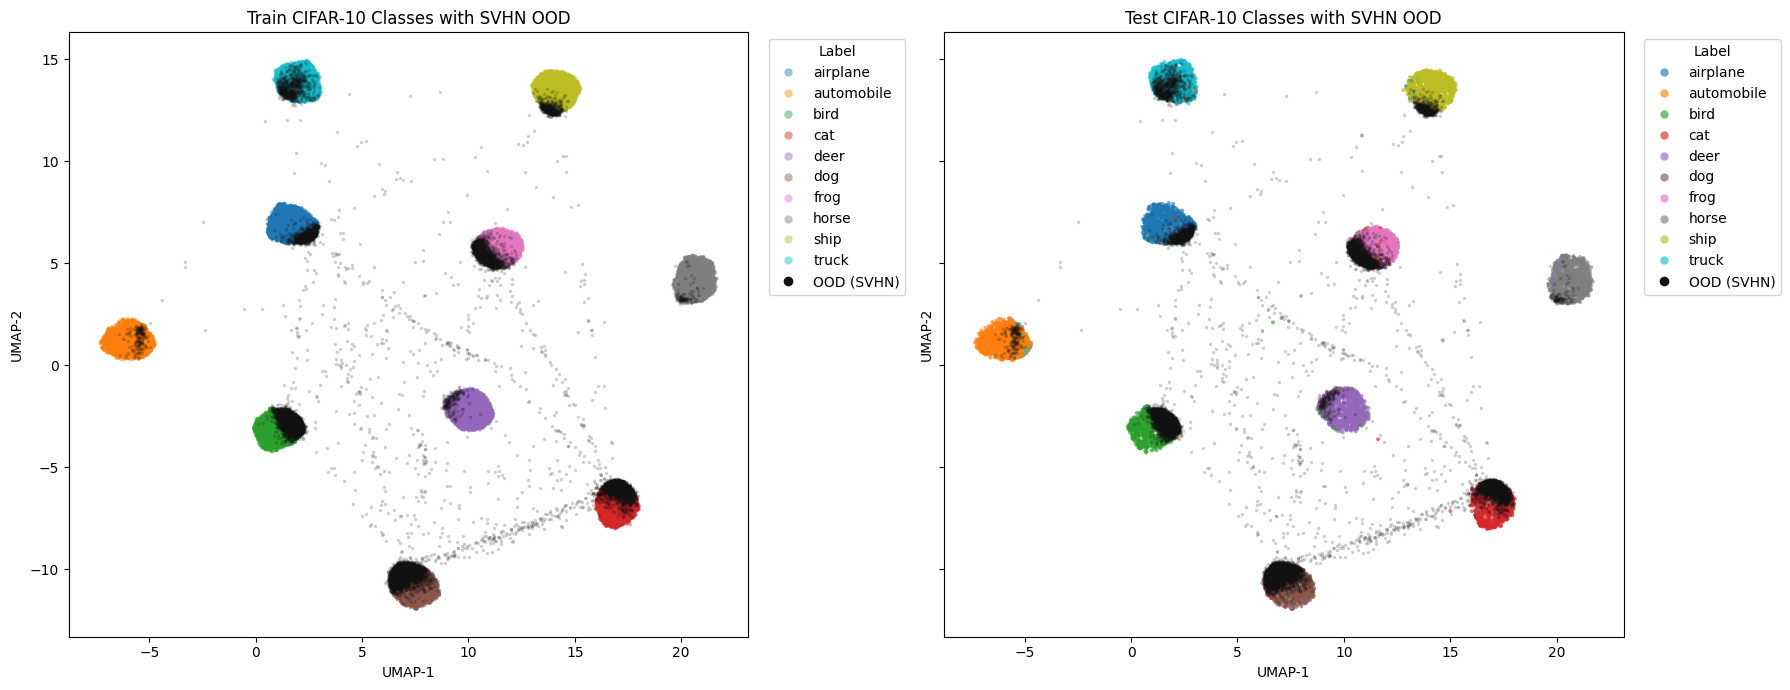

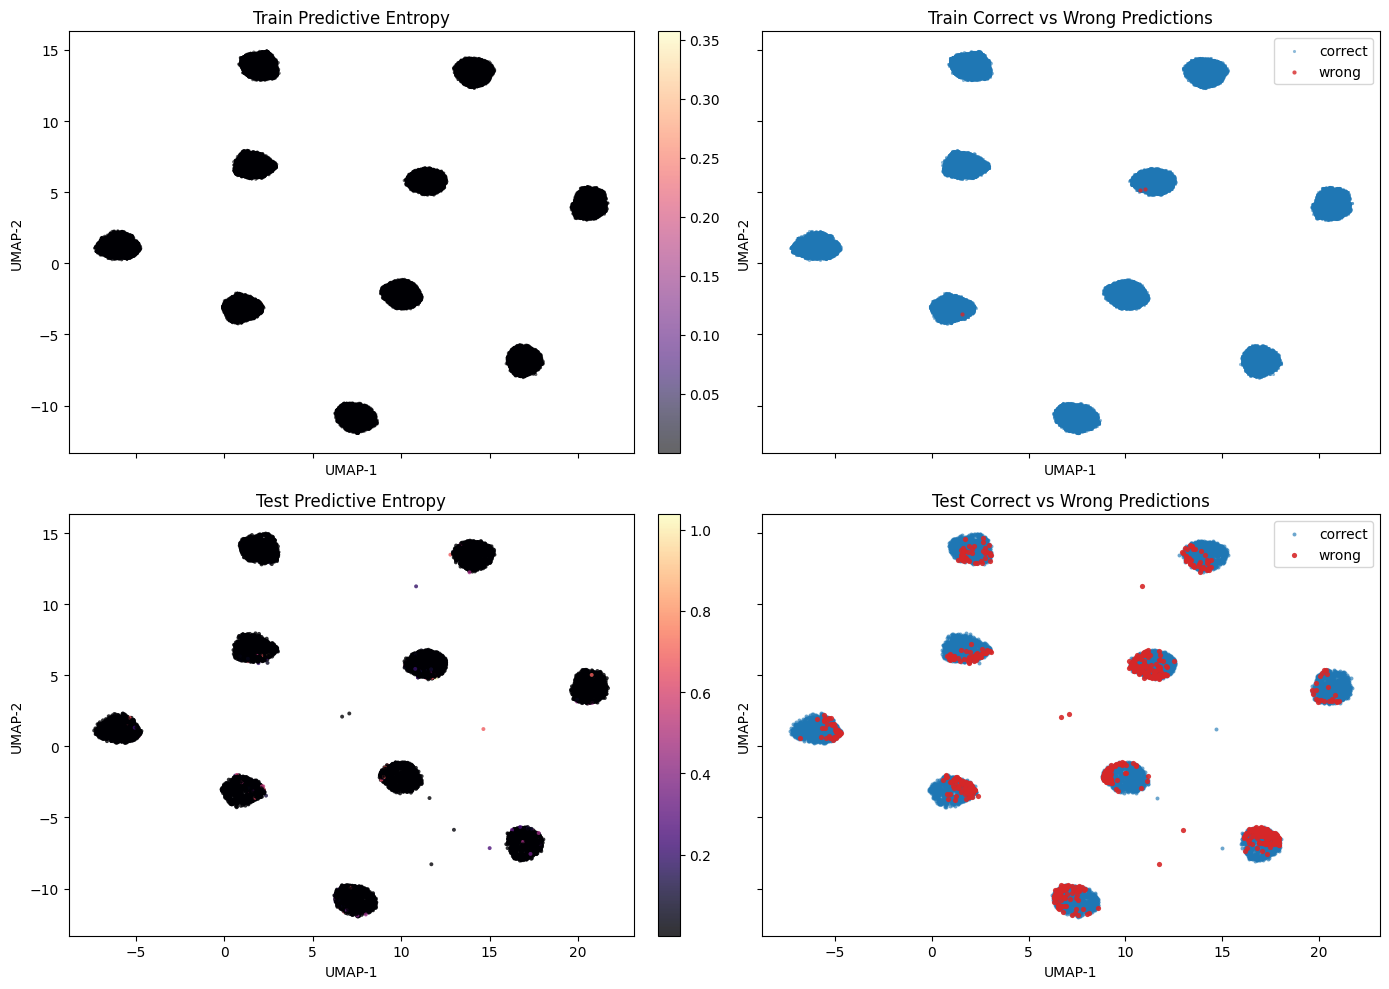

SVHN OOD label-assigned GMM with -log p(x): AUROC=0.8705, AUPR=0.9096
SVHN OOD EM GMM with -log p(x): AUROC=0.8704, AUPR=0.9095
SVHN OOD Dempster-Shafer: AUROC=0.9376, AUPR=0.9715
SVHN OOD max-prob: AUROC=0.9051, AUPR=0.9475
CIFAR-100 OOD label-assigned GMM with -log p(x): AUROC=0.8473, AUPR=0.8139
CIFAR-100 OOD EM GMM with -log p(x): AUROC=0.8472, AUPR=0.8137
CIFAR-100 OOD Dempster-Shafer: AUROC=0.8647, AUPR=0.8501
CIFAR-100 OOD max-prob: AUROC=0.8593, AUPR=0.8249


In [6]:
confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
for true_label, pred_label in zip(test_labels, test_posterior_pred):
    confusion[true_label, pred_label] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(confusion, cmap="Blues")
ax.set_title("GMM Posterior Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(np.arange(num_classes), labels=classes, rotation=45, ha="right")
ax.set_yticks(np.arange(num_classes), labels=classes)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, calibration, ece, title in [
    (axes[0], train_calibration, train_posterior_ece, "Train Reliability Diagram"),
    (axes[1], test_calibration, test_posterior_ece, "Test Reliability Diagram"),
]:
    bin_edges = calibration["bin_edges"]
    bin_width = bin_edges[1] - bin_edges[0]
    valid = ~np.isnan(calibration["bin_acc"])

    ax.bar(
        calibration["bin_centers"][valid],
        calibration["bin_acc"][valid],
        width=bin_width * 0.9,
        color="#4c78a8",
        alpha=0.75,
        edgecolor="white",
        label="accuracy",
    )
    ax.plot(
        calibration["bin_centers"][valid],
        calibration["bin_conf"][valid],
        color="#f58518",
        marker="o",
        linewidth=1.5,
        label="mean confidence",
    )
    ax.plot([0, 1], [0, 1], linestyle="--", color="#444444", linewidth=1.25, label="ideal")
    ax.set_title(f"{title} (ECE={ece:.4f})")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.2, linewidth=0.5)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

if svhn_embeddings is None:
    raise KeyError("svhn_embeddings not found in embedding file. Re-run sngp_extract_embeddings.ipynb first.")
if umap is None:
    raise ImportError("Install umap-learn before running this notebook.")

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
train_embedding_2d = umap_model.fit_transform(train_embeddings)
test_embedding_2d = umap_model.transform(test_embeddings)
svhn_embedding_2d = umap_model.transform(svhn_embeddings)
print("computed train/test/svhn UMAP:", train_embedding_2d.shape, test_embedding_2d.shape, svhn_embedding_2d.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True)

train_scatter = axes[0].scatter(
    train_embedding_2d[:, 0],
    train_embedding_2d[:, 1],
    c=train_labels,
    cmap="tab10",
    s=5,
    alpha=0.45,
    linewidths=0,
)
axes[0].scatter(
    svhn_embedding_2d[:, 0],
    svhn_embedding_2d[:, 1],
    c="#111111",
    s=6,
    alpha=0.20,
    linewidths=0,
    label="OOD (SVHN)",
)
axes[0].set_title("Train CIFAR-10 Classes with SVHN OOD")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

handles, _ = train_scatter.legend_elements(num=len(classes))
axes[0].legend(handles + [plt.Line2D([0], [0], marker='o', color='w', label='OOD (SVHN)', markerfacecolor='#111111', markersize=8)], list(classes) + ["OOD (SVHN)"], title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")

test_scatter = axes[1].scatter(
    test_embedding_2d[:, 0],
    test_embedding_2d[:, 1],
    c=test_labels,
    cmap="tab10",
    s=8,
    alpha=0.65,
    linewidths=0,
)
axes[1].scatter(
    svhn_embedding_2d[:, 0],
    svhn_embedding_2d[:, 1],
    c="#111111",
    s=6,
    alpha=0.20,
    linewidths=0,
    label="OOD (SVHN)",
)
axes[1].set_title("Test CIFAR-10 Classes with SVHN OOD")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

handles, _ = test_scatter.legend_elements(num=len(classes))
axes[1].legend(handles + [plt.Line2D([0], [0], marker='o', color='w', label='OOD (SVHN)', markerfacecolor='#111111', markersize=8)], list(classes) + ["OOD (SVHN)"], title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

train_entropy_plot = axes[0, 0].scatter(
    train_embedding_2d[:, 0],
    train_embedding_2d[:, 1],
    c=train_entropy,
    cmap="magma",
    s=5,
    alpha=0.6,
    linewidths=0,
)
axes[0, 0].set_title("Train Predictive Entropy")
axes[0, 0].set_xlabel("UMAP-1")
axes[0, 0].set_ylabel("UMAP-2")
plt.colorbar(train_entropy_plot, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].scatter(
    train_embedding_2d[train_correct_mask, 0],
    train_embedding_2d[train_correct_mask, 1],
    c="#1f77b4",
    s=5,
    alpha=0.5,
    linewidths=0,
    label="correct",
)
axes[0, 1].scatter(
    train_embedding_2d[~train_correct_mask, 0],
    train_embedding_2d[~train_correct_mask, 1],
    c="#d62728",
    s=9,
    alpha=0.8,
    linewidths=0,
    label="wrong",
)
axes[0, 1].set_title("Train Correct vs Wrong Predictions")
axes[0, 1].set_xlabel("UMAP-1")
axes[0, 1].set_ylabel("UMAP-2")
axes[0, 1].legend(loc="best")

test_entropy_plot = axes[1, 0].scatter(
    test_embedding_2d[:, 0],
    test_embedding_2d[:, 1],
    c=test_entropy,
    cmap="magma",
    s=8,
    alpha=0.8,
    linewidths=0,
)
axes[1, 0].set_title("Test Predictive Entropy")
axes[1, 0].set_xlabel("UMAP-1")
axes[1, 0].set_ylabel("UMAP-2")
plt.colorbar(test_entropy_plot, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].scatter(
    test_embedding_2d[test_correct_mask, 0],
    test_embedding_2d[test_correct_mask, 1],
    c="#1f77b4",
    s=8,
    alpha=0.65,
    linewidths=0,
    label="correct",
)
axes[1, 1].scatter(
    test_embedding_2d[~test_correct_mask, 0],
    test_embedding_2d[~test_correct_mask, 1],
    c="#d62728",
    s=14,
    alpha=0.9,
    linewidths=0,
    label="wrong",
)
axes[1, 1].set_title("Test Correct vs Wrong Predictions")
axes[1, 1].set_xlabel("UMAP-1")
axes[1, 1].set_ylabel("UMAP-2")
axes[1, 1].legend(loc="best")

plt.tight_layout()
plt.show()


def dempster_shafer_uncertainty(logits):
    exp_logits = np.exp(logits)
    return logits.shape[1] / (np.sum(exp_logits, axis=1) + logits.shape[1])


def max_prob_uncertainty(probs):
    return 1.0 - np.max(probs, axis=1)


def ood_metrics(id_scores, ood_scores):
    from sklearn.metrics import average_precision_score, roc_auc_score

    y_true = np.concatenate([
        np.zeros(len(id_scores), dtype=np.int64),
        np.ones(len(ood_scores), dtype=np.int64),
    ])
    y_score = np.concatenate([id_scores, ood_scores])
    return {
        "auroc": roc_auc_score(y_true, y_score),
        "aupr": average_precision_score(y_true, y_score),
    }


def evaluate_ood_dataset(name, ood_embeddings, ood_logits_key=None, ood_probs_key=None):
    dataset_gmm = gmm_probabilities(
        ood_embeddings,
        class_priors,
        class_means,
        class_covariances,
    )
    em_dataset_gmm = gmm_probabilities(
        ood_embeddings,
        em_priors,
        em_means,
        em_covariances,
    )

    label_metrics = ood_metrics(-test_gmm["log_px"], -dataset_gmm["log_px"])
    em_metrics = ood_metrics(-em_test_gmm["log_px"], -em_dataset_gmm["log_px"])

    print(f"{name} OOD label-assigned GMM with -log p(x): AUROC={label_metrics['auroc']:.4f}, AUPR={label_metrics['aupr']:.4f}")
    print(f"{name} OOD EM GMM with -log p(x): AUROC={em_metrics['auroc']:.4f}, AUPR={em_metrics['aupr']:.4f}")

    baseline_metrics = {}
    if ood_logits_key is not None and ood_probs_key is not None and all(
        key in data for key in ["test_logits", "test_probs", ood_logits_key, ood_probs_key]
    ):
        ds_metrics = ood_metrics(
            dempster_shafer_uncertainty(data["test_logits"]),
            dempster_shafer_uncertainty(data[ood_logits_key]),
        )
        mp_metrics = ood_metrics(
            max_prob_uncertainty(data["test_probs"]),
            max_prob_uncertainty(data[ood_probs_key]),
        )
        baseline_metrics["dempster_shafer"] = ds_metrics
        baseline_metrics["max_prob"] = mp_metrics

        print(f"{name} OOD Dempster-Shafer: AUROC={ds_metrics['auroc']:.4f}, AUPR={ds_metrics['aupr']:.4f}")
        print(f"{name} OOD max-prob: AUROC={mp_metrics['auroc']:.4f}, AUPR={mp_metrics['aupr']:.4f}")

    return {
        "gmm": dataset_gmm,
        "em_gmm": em_dataset_gmm,
        "label_metrics": label_metrics,
        "em_metrics": em_metrics,
        "baseline_metrics": baseline_metrics,
    }


if svhn_embeddings is not None:
    svhn_ood = evaluate_ood_dataset(
        "SVHN",
        svhn_embeddings,
        ood_logits_key="svhn_logits",
        ood_probs_key="svhn_probs",
    )
    svhn_gmm = svhn_ood["gmm"]
    em_svhn_gmm = svhn_ood["em_gmm"]
    label_gmm_svhn_metrics = svhn_ood["label_metrics"]
    em_gmm_svhn_metrics = svhn_ood["em_metrics"]
    gmm_svhn_auroc = label_gmm_svhn_metrics["auroc"]
    gmm_svhn_aupr = label_gmm_svhn_metrics["aupr"]
    em_gmm_svhn_auroc = em_gmm_svhn_metrics["auroc"]
    em_gmm_svhn_aupr = em_gmm_svhn_metrics["aupr"]
    if "dempster_shafer" in svhn_ood["baseline_metrics"]:
        ds_svhn_auroc = svhn_ood["baseline_metrics"]["dempster_shafer"]["auroc"]
        ds_svhn_aupr = svhn_ood["baseline_metrics"]["dempster_shafer"]["aupr"]
        mp_svhn_auroc = svhn_ood["baseline_metrics"]["max_prob"]["auroc"]
        mp_svhn_aupr = svhn_ood["baseline_metrics"]["max_prob"]["aupr"]
else:
    print("Skipping SVHN OOD: svhn_embeddings not found in embedding file.")

if cifar100_test_embeddings is not None:
    cifar100_ood = evaluate_ood_dataset(
        "CIFAR-100",
        cifar100_test_embeddings,
        ood_logits_key="cifar100_test_logits",
        ood_probs_key="cifar100_test_probs",
    )
    cifar100_test_gmm = cifar100_ood["gmm"]
    em_cifar100_test_gmm = cifar100_ood["em_gmm"]
    label_gmm_cifar100_metrics = cifar100_ood["label_metrics"]
    em_gmm_cifar100_metrics = cifar100_ood["em_metrics"]
    gmm_cifar100_auroc = label_gmm_cifar100_metrics["auroc"]
    gmm_cifar100_aupr = label_gmm_cifar100_metrics["aupr"]
    em_gmm_cifar100_auroc = em_gmm_cifar100_metrics["auroc"]
    em_gmm_cifar100_aupr = em_gmm_cifar100_metrics["aupr"]
    if "dempster_shafer" in cifar100_ood["baseline_metrics"]:
        ds_cifar100_auroc = cifar100_ood["baseline_metrics"]["dempster_shafer"]["auroc"]
        ds_cifar100_aupr = cifar100_ood["baseline_metrics"]["dempster_shafer"]["aupr"]
        mp_cifar100_auroc = cifar100_ood["baseline_metrics"]["max_prob"]["auroc"]
        mp_cifar100_aupr = cifar100_ood["baseline_metrics"]["max_prob"]["aupr"]
else:
    print("Skipping CIFAR-100 OOD: cifar100_test_embeddings not found in embedding file.")

if svhn_embeddings is None and cifar100_test_embeddings is None:
    raise KeyError("No OOD embeddings found in embedding file. Re-run sngp_extract_embeddings.ipynb first.")



In [7]:
# result_path = REPO_ROOT / "notebooks" / "gmm" / f"gmm_results_{checkpoint_id}.npz"
# np.savez_compressed(
#     result_path,
#     class_priors=class_priors,
#     class_means=class_means,
#     class_covariances=class_covariances,
#     covariance_reg=covariance_reg,
#     em_priors=em_priors,
#     em_means=em_means,
#     em_covariances=em_covariances,
#     em_covariance_reg=em_covariance_reg,
#     em_converged=em_model.converged_,
#     em_n_iter=em_model.n_iter_,
#     em_lower_bound=em_model.lower_bound_,
#     train_log_px=train_gmm["log_px"],
#     test_log_px=test_gmm["log_px"],
#     svhn_log_px=svhn_gmm["log_px"] if "svhn_gmm" in locals() else np.array([]),
#     cifar100_test_log_px=cifar100_test_gmm["log_px"] if "cifar100_test_gmm" in locals() else np.array([]),
#     em_train_log_px=em_train_gmm["log_px"],
#     em_test_log_px=em_test_gmm["log_px"],
#     em_svhn_log_px=em_svhn_gmm["log_px"] if "em_svhn_gmm" in locals() else np.array([]),
#     em_cifar100_test_log_px=em_cifar100_test_gmm["log_px"] if "em_cifar100_test_gmm" in locals() else np.array([]),
#     train_posterior_probs=train_gmm["posterior"],
#     test_posterior_probs=test_gmm["posterior"],
#     train_posterior_pred=train_posterior_pred,
#     test_posterior_pred=test_posterior_pred,
#     train_labels=train_labels,
#     test_labels=test_labels,
#     svhn_labels=svhn_labels,
#     train_entropy=train_entropy,
#     test_entropy=test_entropy,
#     train_correct_mask=train_correct_mask,
#     test_correct_mask=test_correct_mask,
#     train_posterior_ece=train_posterior_ece,
#     test_posterior_ece=test_posterior_ece,
#     train_calibration_bin_edges=train_calibration["bin_edges"],
#     train_calibration_bin_centers=train_calibration["bin_centers"],
#     train_calibration_bin_acc=train_calibration["bin_acc"],
#     train_calibration_bin_conf=train_calibration["bin_conf"],
#     train_calibration_bin_frac=train_calibration["bin_frac"],
#     test_calibration_bin_edges=test_calibration["bin_edges"],
#     test_calibration_bin_centers=test_calibration["bin_centers"],
#     test_calibration_bin_acc=test_calibration["bin_acc"],
#     test_calibration_bin_conf=test_calibration["bin_conf"],
#     test_calibration_bin_frac=test_calibration["bin_frac"],
#     train_umap=train_embedding_2d,
#     test_umap=test_embedding_2d,
#     svhn_umap=svhn_embedding_2d,
#     gmm_svhn_auroc=gmm_svhn_auroc,
#     gmm_svhn_aupr=gmm_svhn_aupr,
#     em_gmm_svhn_auroc=em_gmm_svhn_auroc,
#     em_gmm_svhn_aupr=em_gmm_svhn_aupr,
#     ds_svhn_auroc=ds_svhn_auroc if "ds_svhn_auroc" in locals() else np.nan,
#     ds_svhn_aupr=ds_svhn_aupr if "ds_svhn_aupr" in locals() else np.nan,
#     mp_svhn_auroc=mp_svhn_auroc if "mp_svhn_auroc" in locals() else np.nan,
#     mp_svhn_aupr=mp_svhn_aupr if "mp_svhn_aupr" in locals() else np.nan,
#     gmm_cifar100_auroc=gmm_cifar100_auroc if "gmm_cifar100_auroc" in locals() else np.nan,
#     gmm_cifar100_aupr=gmm_cifar100_aupr if "gmm_cifar100_aupr" in locals() else np.nan,
#     em_gmm_cifar100_auroc=em_gmm_cifar100_auroc if "em_gmm_cifar100_auroc" in locals() else np.nan,
#     em_gmm_cifar100_aupr=em_gmm_cifar100_aupr if "em_gmm_cifar100_aupr" in locals() else np.nan,
#     ds_cifar100_auroc=ds_cifar100_auroc if "ds_cifar100_auroc" in locals() else np.nan,
#     ds_cifar100_aupr=ds_cifar100_aupr if "ds_cifar100_aupr" in locals() else np.nan,
#     mp_cifar100_auroc=mp_cifar100_auroc if "mp_cifar100_auroc" in locals() else np.nan,
#     mp_cifar100_aupr=mp_cifar100_aupr if "mp_cifar100_aupr" in locals() else np.nan,
#     confusion=confusion,
#     classes=classes,
#     checkpoint_id=checkpoint_id,
#     embedding_path=str(EMBEDDING_PATH),
#     train_posterior_accuracy=train_posterior_acc,
#     test_posterior_accuracy=test_posterior_acc,
#     train_posterior_nll=train_posterior_nll,
#     test_posterior_nll=test_posterior_nll,
# )
# print("saved:", result_path)

